# 🧠 Deep Learning from Scratch /Section 2
# Neural Networks: Multi-Layer Perceptron (MLP)
---
**Builds on:** Section 1 (Perceptron)  
**Goal:** Understand how stacking layers creates universal function approximators.

---
## 📌 Table of Contents
1. [Intuition](#intuition)
2. [Activation Functions](#activations)
3. [MLP Implementation](#mlp)
4. [Forward Propagation](#forward)
5. [Training with Mini-Batch SGD](#train)
6. [Experiment: Spiral Dataset](#exp)


## 1. Intuition <a id="intuition"></a>

A single perceptron draws **one straight line**. What if the boundary needs to be curved?

**Stack layers:**  each layer applies a linear transform + activation, creating complex, non-linear mappings.

```
 Input Layer    Hidden Layer 1   Hidden Layer 2   Output Layer
 ───────────    ──────────────   ──────────────   ────────────
    x₁ ─────── h₁⁽¹⁾ ─────── h₁⁽²⁾ ──────── ŷ₁
    x₂ ─────── h₂⁽¹⁾ ─────── h₂⁽²⁾ ──────── ŷ₂
    x₃ ─────── h₃⁽¹⁾ ─────── h₃⁽²⁾ ──────── ŷ₃
               ⋮                ⋮
```

**Universal approximation theorem:** An MLP with a single hidden layer and enough neurons can approximate *any* continuous function to arbitrary precision.


## 2. Activation Functions <a id="activations"></a>

Activations are applied element-wise after every linear layer. Without them, any stack of linear layers collapses to a single linear layer.

| Function | Formula | Use |
|---|---|---|
| **ReLU** | $\max(0, z)$ | Hidden layers — fast, avoids vanishing gradient |
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | Binary output — squashes to $(0,1)$ |
| **Softmax** | $\frac{e^{z_k}}{\sum_j e^{z_j}}$ | Multi-class output — produces probability distribution |

### Why ReLU?
Sigmoid and tanh saturate (flat gradient) for large $|z|$, making learning very slow in deep networks. ReLU has a **constant gradient of 1** for positive inputs.


In [7]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)


plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4d",
    "axes.labelcolor":  "#c8ccd8",
    "xtick.color":      "#c8ccd8",
    "ytick.color":      "#c8ccd8",
    "text.color":       "#c8ccd8",
    "grid.color":       "#2a2d3d",
    "grid.alpha":       0.5,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4d",
    "font.family":      "monospace",
})

ACCENT = "#7c83ff"
GREEN  = "#56d364"
ORANGE = "#ffa657"
PINK   = "#f778ba"
YELLOW = "#e3b341"

print(" Setup complete — NumPy", np.__version__)


 Setup complete — NumPy 2.0.2


In [8]:


def relu(z):
    """ReLU: max(0, z)"""
    return np.maximum(0, z)

def relu_derivative(z):
    """d/dz ReLU = 1 if z > 0 else 0"""
    return (z > 0).astype(float)

def sigmoid(z):
    """Numerically-stable sigmoid: σ(z) = 1 / (1 + e^{-z})"""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def sigmoid_derivative(z):
    """dσ/dz = σ(z)(1 − σ(z))"""
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
    """Softmax — numerically stable (subtract row max before exp)."""
    z_s   = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_s)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

print(" Activation functions defined")


 Activation functions defined


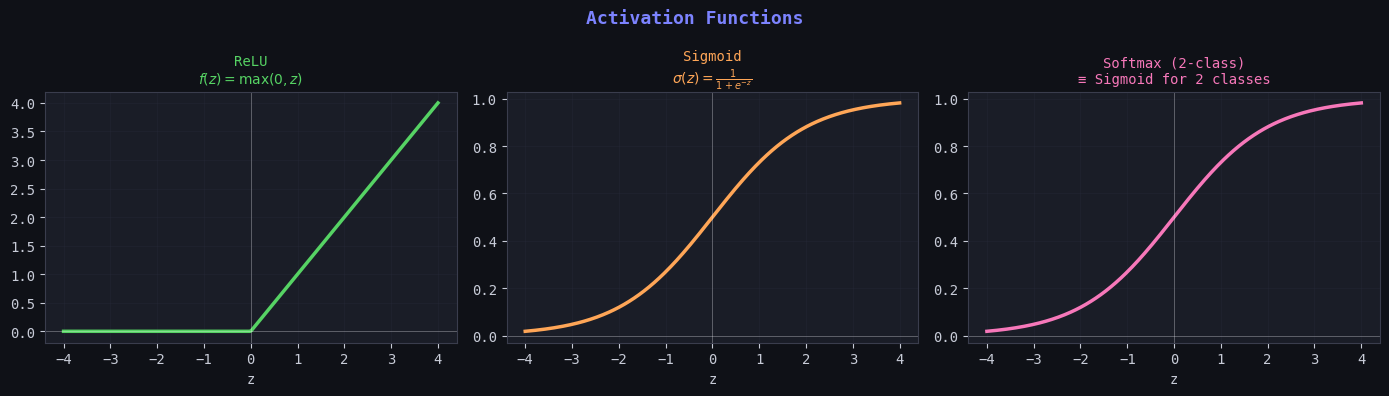

In [9]:
z = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Activation Functions", fontsize=13, color=ACCENT, fontweight="bold")

specs = [
    ("ReLU",             relu(z),    GREEN,  r"$f(z) = \max(0,z)$"),
    ("Sigmoid",          sigmoid(z), ORANGE, r"$\sigma(z) = \frac{1}{1+e^{-z}}$"),
    ("Softmax (2-class)", sigmoid(z), PINK,  "≡ Sigmoid for 2 classes"),
]

for ax, (name, vals, col, eq) in zip(axes, specs):
    ax.set_facecolor("#1a1d27")
    ax.plot(z, vals, color=col, lw=2.5)
    ax.axhline(0, color="white", lw=0.5, alpha=0.4)
    ax.axvline(0, color="white", lw=0.5, alpha=0.4)
    ax.set_title(f"{name}\n{eq}", color=col, fontsize=10)   # ← \n added
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("z")

plt.tight_layout()
plt.show()

## 3. MLP Implementation <a id="mlp"></a>

### Layer equation
$$\mathbf{Z}^{(l)} = \mathbf{A}^{(l-1)} \mathbf{W}^{(l)} + \mathbf{b}^{(l)}$$
$$\mathbf{A}^{(l)} = f(\mathbf{Z}^{(l)})$$

Where $f$ is ReLU for hidden layers and Softmax for the output layer.

### Weight Initialisation — He Init
Starting weights at zero causes symmetry (all neurons learn the same thing). We use **He initialisation** (optimal for ReLU):
$$W_{ij} \sim \mathcal{N}\left(0,\, \sqrt{\frac{2}{\text{fan\_in}}}\right)$$


In [10]:
class MLP:


    def __init__(self, layer_sizes, lr=0.01, n_epochs=500, batch_size=32):
        self.layer_sizes = layer_sizes
        self.lr          = lr
        self.n_epochs    = n_epochs
        self.batch_size  = batch_size
        self.n_layers    = len(layer_sizes) - 1
        self.loss_history = []

        # He initialisation for every weight matrix
        self.W, self.b = [], []
        for l in range(self.n_layers):
            fan_in, fan_out = layer_sizes[l], layer_sizes[l + 1]
            self.W.append(np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in))
            self.b.append(np.zeros((1, fan_out)))

    def forward(self, X):
    
        self.A = [X]    # A[0] = raw input
        self.Z = []

        for l in range(self.n_layers):
            Z_l = self.A[l] @ self.W[l] + self.b[l]   # linear
            self.Z.append(Z_l)
            A_l = relu(Z_l) if l < self.n_layers - 1 else softmax(Z_l)
            self.A.append(A_l)

        return self.A[-1]    

   
    @staticmethod
    def cross_entropy_loss(y_pred, y_true):
        """L = -(1/N) Σ y_true · log(y_pred)  [y_true is one-hot]"""
        return -np.sum(y_true * np.log(y_pred + 1e-12)) / y_pred.shape[0]


    def backward(self, y_true):
        """Chain rule: compute dL/dW and dL/db for every layer."""
        n = y_true.shape[0]
        self.dW = [None] * self.n_layers
        self.db = [None] * self.n_layers

        # Output layer delta: combined softmax + cross-entropy gradient
        dA = (self.A[-1] - y_true) / n

        for l in reversed(range(self.n_layers)):
            self.dW[l] = self.A[l].T @ dA
            self.db[l] = np.sum(dA, axis=0, keepdims=True)
            if l > 0:
                dA = (dA @ self.W[l].T) * relu_derivative(self.Z[l - 1])

    def update_weights(self):
        """Gradient descent: θ ← θ - η·∇θ"""
        for l in range(self.n_layers):
            self.W[l] -= self.lr * self.dW[l]
            self.b[l] -= self.lr * self.db[l]

    @staticmethod
    def to_one_hot(y, n_classes):
        oh = np.zeros((len(y), n_classes))
        oh[np.arange(len(y)), y] = 1
        return oh


    def fit(self, X, y):
        n = X.shape[0]
        n_classes = len(np.unique(y))
        y_oh = self.to_one_hot(y, n_classes)

        for epoch in range(self.n_epochs):
            perm = np.random.permutation(n)
            epoch_loss, n_batches = 0.0, 0

            for start in range(0, n, self.batch_size):
                idx_b = perm[start : start + self.batch_size]
                Xb, yb = X[idx_b], y_oh[idx_b]

                y_pred = self.forward(Xb)
                epoch_loss += self.cross_entropy_loss(y_pred, yb)

                self.backward(yb)
                self.update_weights()
                n_batches += 1

            self.loss_history.append(epoch_loss / n_batches)

            if (epoch + 1) % 100 == 0:
                acc = self.accuracy(X, y)
                print(f"  Epoch {epoch+1:4d}/{self.n_epochs}  "
                      f"loss={self.loss_history[-1]:.4f}  acc={acc*100:.1f}%")

        return self

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)




## 5. Experiment: 3-Class Spiral Dataset <a id="exp"></a>

The **spiral dataset** is a classic test: three interleaved spirals that are *impossible* for a linear classifier but solvable by an MLP.


In [11]:

def make_spiral(n_per_class=150, n_classes=3, noise=0.15):
    X_list, y_list = [], []
    for c in range(n_classes):
        r = np.linspace(0.0, 1.0, n_per_class)
        t = np.linspace(c * 4, (c + 1) * 4, n_per_class) +             np.random.randn(n_per_class) * noise
        X_list.append(np.column_stack([r * np.sin(t), r * np.cos(t)]))
        y_list.append(np.full(n_per_class, c))
    return np.vstack(X_list), np.hstack(y_list)

X_sp, y_sp = make_spiral(n_per_class=150, n_classes=3, noise=0.15)
X_sp = (X_sp - X_sp.mean(0)) / (X_sp.std(0) + 1e-8)   # normalise

print(f"  Dataset shape: {X_sp.shape}, classes: {np.unique(y_sp)}")


mlp = MLP(layer_sizes=[2, 64, 64, 3], lr=0.05, n_epochs=500, batch_size=64)
mlp.fit(X_sp, y_sp)
print(f"\n  🎯 Final Accuracy: {mlp.accuracy(X_sp, y_sp)*100:.1f}%")


  Dataset shape: (450, 2), classes: [0 1 2]
  Epoch  100/500  loss=0.0631  acc=98.9%
  Epoch  200/500  loss=0.0318  acc=99.6%
  Epoch  300/500  loss=0.0617  acc=98.2%
  Epoch  400/500  loss=0.0216  acc=99.6%
  Epoch  500/500  loss=0.0196  acc=99.6%

  🎯 Final Accuracy: 99.6%


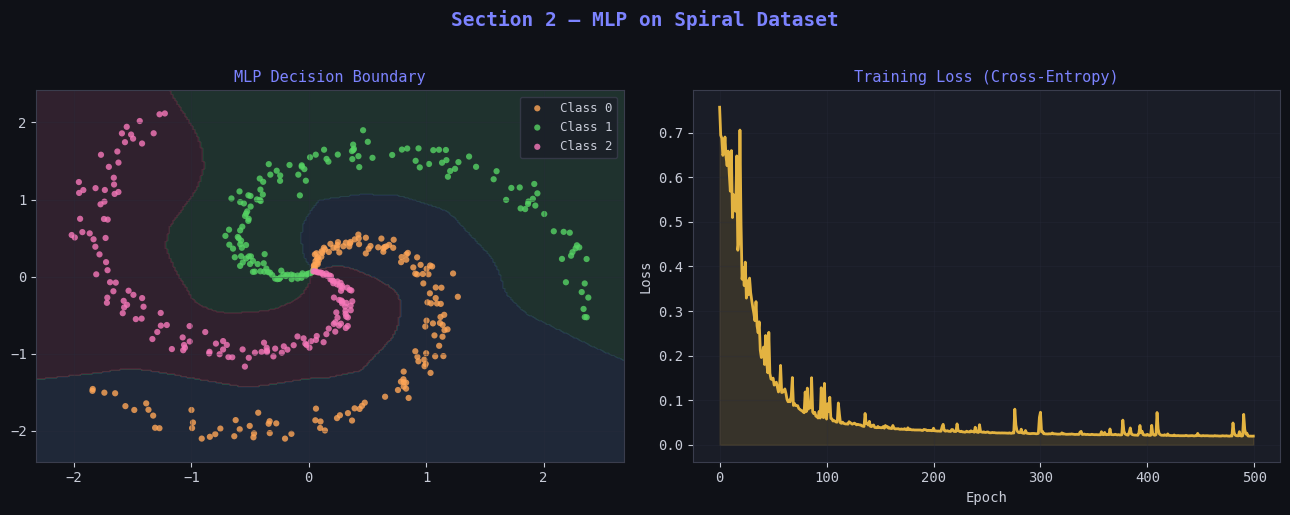

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0f1117")
fig.suptitle("Section 2 — MLP on Spiral Dataset", fontsize=14,
             color=ACCENT, fontweight="bold", y=1.02)

colors_3 = [ORANGE, GREEN, PINK]

ax = axes[0]
ax.set_facecolor("#1a1d27")
ax.set_title("MLP Decision Boundary", color=ACCENT, fontsize=11)
xr = np.linspace(X_sp[:,0].min()-0.3, X_sp[:,0].max()+0.3, 300)
yr = np.linspace(X_sp[:,1].min()-0.3, X_sp[:,1].max()+0.3, 300)
xx, yy = np.meshgrid(xr, yr)
Z_mlp = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
cmap = ListedColormap(["#2a3d5a","#2a5a3d","#5a2a3d"])
ax.contourf(xx, yy, Z_mlp, alpha=0.35, cmap=cmap)
for c, col in enumerate(colors_3):
    ax.scatter(X_sp[y_sp==c,0], X_sp[y_sp==c,1],
               c=col, s=20, alpha=0.8, edgecolors="none", label=f"Class {c}")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.set_facecolor("#1a1d27")
ax2.set_title("Training Loss (Cross-Entropy)", color=ACCENT, fontsize=11)
ax2.plot(mlp.loss_history, color=YELLOW, lw=2)
ax2.fill_between(range(len(mlp.loss_history)), mlp.loss_history,
                 alpha=0.15, color=YELLOW)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 🔑 Key Takeaways

| Concept | Detail |
|---|---|
| **Depth** | More layers = more complex decision boundaries |
| **Width** | More neurons per layer = more capacity |
| **ReLU** | Non-linear activation that enables learning |
| **Softmax** | Converts raw scores to probabilities |
| **Mini-batch SGD** | Stochastic updates stabilise and speed up training |

➡️ **Next:** Section 3 derives exactly *how* we compute the gradients that make training work — Backpropagation.
